In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn shap sqlalchemy

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.4 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.4 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.4 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.4 MB ? eta -:--:--
   -------- ------------------------------- 0.5/2.4 MB 381.6 kB/s eta 0:00:05
   -------- ------------------------------- 0.5/2.4 MB 381.6 kB/s eta 0:00:05
   -------- ------------------------------- 0.5/2.4 MB 381.6 kB/s eta 0:00:05
   ------------ --------------------------- 0.8/2.4 MB 385.8 kB/s eta 0:00:05
   ----------------- ---------------------- 1.0/2.4 MB 503.5 kB/s eta 0:00:03
   ----------------- ---------------------- 1.0/2.4 MB 503.5 kB/s eta 0:00:03


[notice] A new release of pip is available: 26.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import shap

In [4]:
df = pd.read_csv("netflix_customer_churn.csv")

In [5]:
df.shape

(5000, 14)

In [6]:
df.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000


In [7]:
df.isnull().sum()

customer_id               0
age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64

In [8]:
df.columns.tolist()

['customer_id',
 'age',
 'gender',
 'subscription_type',
 'watch_hours',
 'last_login_days',
 'region',
 'device',
 'monthly_fee',
 'churned',
 'payment_method',
 'number_of_profiles',
 'avg_watch_time_per_day',
 'favorite_genre']

In [9]:
df["churned"].value_counts()

churned
1    2515
0    2485
Name: count, dtype: int64

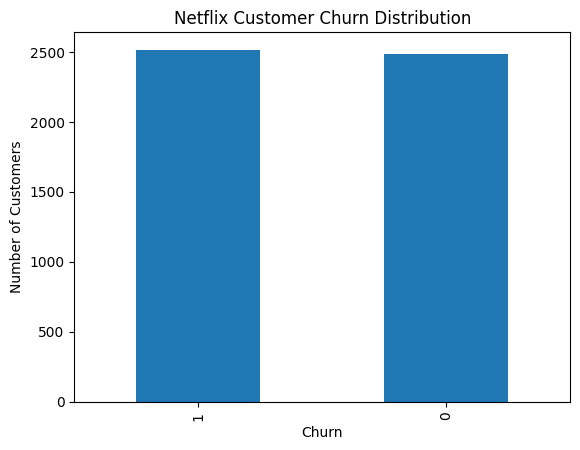

In [10]:
df["churned"].value_counts().plot(
    kind="bar"
)

plt.title("Netflix Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [11]:
df["churned"].value_counts(normalize=True) * 100

churned
1    50.3
0    49.7
Name: proportion, dtype: float64

In [13]:
pd.crosstab(
    df["subscription_type"],
    df["churned"],
    normalize="index"
) * 100

churned,0,1
subscription_type,,
Basic,38.169777,61.830223
Premium,56.290608,43.709392
Standard,54.556501,45.443499


In [14]:
df.groupby("churned")["monthly_fee"].mean()

churned
0    14.248350
1    13.125189
Name: monthly_fee, dtype: float64

In [16]:
df.groupby("churned")["watch_hours"].mean()

churned
0    17.449590
1     5.918497
Name: watch_hours, dtype: float64

In [17]:
df.groupby("churned")["last_login_days"].mean()

churned
0    21.771026
1    38.309344
Name: last_login_days, dtype: float64

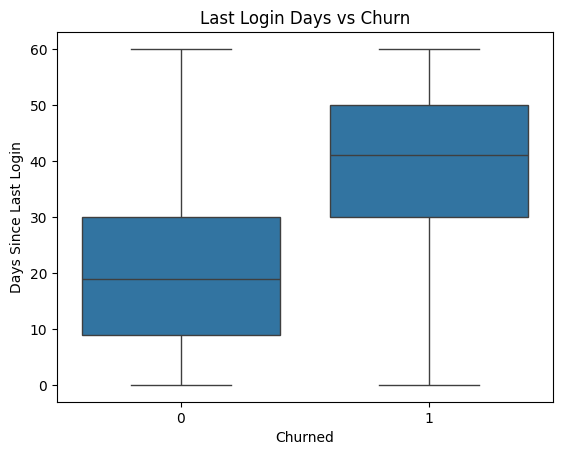

In [18]:
sns.boxplot(
    data=df,
    x="churned",
    y="last_login_days"
)

plt.title("Last Login Days vs Churn")
plt.xlabel("Churned")
plt.ylabel("Days Since Last Login")
plt.show()

In [19]:
df.groupby("churned")["avg_watch_time_per_day"].mean()

churned
0    1.594133
1    0.164048
Name: avg_watch_time_per_day, dtype: float64

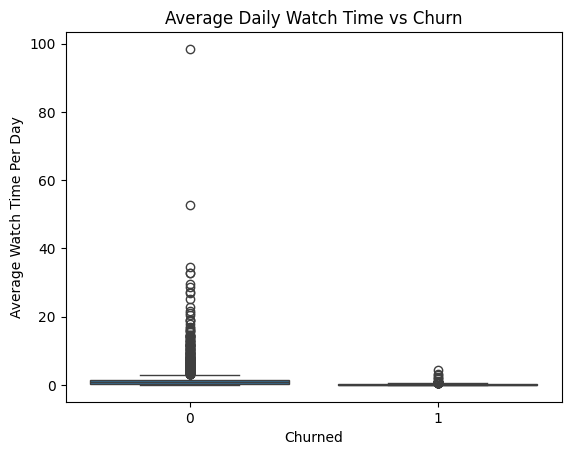

In [20]:
sns.boxplot(
    data=df,
    x="churned",
    y="avg_watch_time_per_day"
)

plt.title("Average Daily Watch Time vs Churn")
plt.xlabel("Churned")
plt.ylabel("Average Watch Time Per Day")
plt.show()

In [21]:
pd.crosstab(
    df["device"],
    df["churned"],
    normalize="index"
) * 100

churned,0,1
device,,
Desktop,50.790306,49.209694
Laptop,48.210736,51.789264
Mobile,49.501992,50.498008
TV,50.050352,49.949648
Tablet,50.000000,50.000000


In [22]:
pd.crosstab(
    df["payment_method"],
    df["churned"],
    normalize="index"
) * 100

churned,0,1
payment_method,,
Credit Card,56.423433,43.576567
Crypto,40.301508,59.698492
Debit Card,56.310680,43.689320
Gift Card,42.213115,57.786885
PayPal,52.923977,47.076023


In [23]:
df["avg_watch_time_per_day"].describe()

count    5000.000000
mean        0.874800
std         2.619824
min         0.000000
25%         0.110000
50%         0.290000
75%         0.720000
max        98.420000
Name: avg_watch_time_per_day, dtype: float64

In [24]:
df["avg_watch_time_per_day"].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

0.25     0.1100
0.50     0.2900
0.75     0.7200
0.90     1.7910
0.95     3.1605
0.99    10.9216
Name: avg_watch_time_per_day, dtype: float64

In [25]:
pd.crosstab(
    df["favorite_genre"],
    df["churned"],
    normalize="index"
) * 100

churned,0,1
favorite_genre,,
Action,47.632712,52.367288
Comedy,50.072993,49.927007
Documentary,49.245542,50.754458
Drama,47.742818,52.257182
Horror,48.527349,51.472651
Romance,51.724138,48.275862
Sci-Fi,52.916667,47.083333


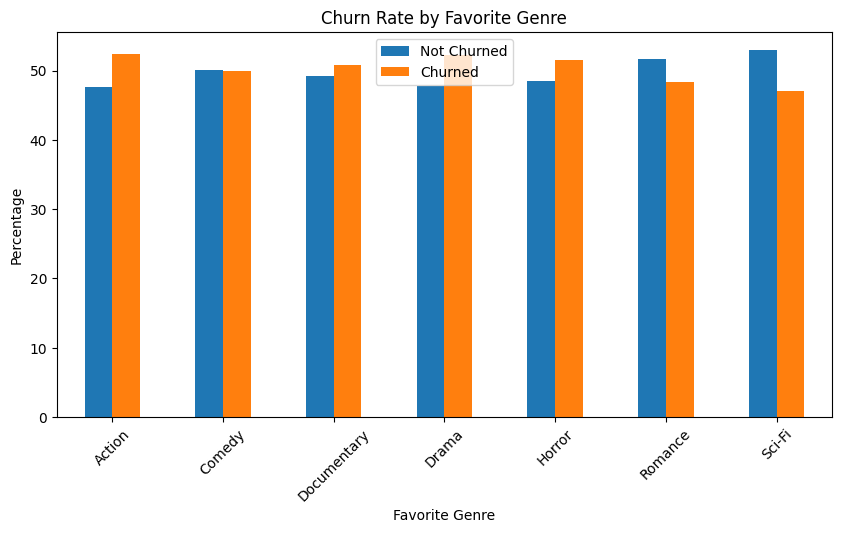

In [26]:
genre_churn = pd.crosstab(
    df["favorite_genre"],
    df["churned"],
    normalize="index"
) * 100

genre_churn.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Churn Rate by Favorite Genre")
plt.xlabel("Favorite Genre")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.legend(["Not Churned", "Churned"])
plt.show()

In [27]:
pd.crosstab(
    df["region"],
    df["churned"],
    normalize="index"
) * 100

churned,0,1
region,,
Africa,51.681196,48.318804
Asia,49.346017,50.653983
Europe,48.327566,51.672434
North America,50.528790,49.471210
Oceania,49.934641,50.065359
South America,48.568156,51.431844


In [28]:
df.isnull().sum()

customer_id               0
age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64

In [29]:
df["customer_id"].duplicated().sum()

np.int64(0)

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
df.dtypes

customer_id                object
age                         int64
gender                     object
subscription_type          object
watch_hours               float64
last_login_days             int64
region                     object
device                     object
monthly_fee               float64
churned                     int64
payment_method             object
number_of_profiles          int64
avg_watch_time_per_day    float64
favorite_genre             object
dtype: object

In [32]:
for col in [
    "gender",
    "subscription_type",
    "region",
    "device",
    "payment_method",
    "favorite_genre"
]:
    print("\n", col)
    print(df[col].unique())


 gender
['Other' 'Female' 'Male']

 subscription_type
['Basic' 'Standard' 'Premium']

 region
['Africa' 'Europe' 'Asia' 'Oceania' 'South America' 'North America']

 device
['TV' 'Mobile' 'Laptop' 'Desktop' 'Tablet']

 payment_method
['Gift Card' 'Crypto' 'Debit Card' 'PayPal' 'Credit Card']

 favorite_genre
['Action' 'Sci-Fi' 'Drama' 'Horror' 'Romance' 'Comedy' 'Documentary']


In [41]:
import sqlite3

connection = sqlite3.connect("netflix_churn.db")

df.to_sql(
    "customers",
    connection,
    if_exists="replace",
    index=False
)

5000

In [42]:
query = """
SELECT *
FROM customers
LIMIT 5;
"""

pd.read_sql(query, connection)

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [43]:
query = """
SELECT
    COUNT(*) AS total_customers,
    SUM(churned) AS churned_customers,
    AVG(churned) * 100 AS churn_rate
FROM customers;
"""

pd.read_sql(query, connection)

,total_customers,churned_customers,churn_rate
0,5000,2515,50.3


In [44]:
query = """
SELECT
    subscription_type,
    COUNT(*) AS total_customers,
    SUM(churned) AS churned_customers,
    AVG(churned) * 100 AS churn_rate
FROM customers
GROUP BY subscription_type
ORDER BY churn_rate DESC;
"""

pd.read_sql(query, connection)

,subscription_type,total_customers,churned_customers,churn_rate
0,Basic,1661,1027,61.830223
1,Standard,1646,748,45.443499
2,Premium,1693,740,43.709392


In [45]:
query = """
SELECT
    payment_method,
    COUNT(*) AS total_customers,
    AVG(churned) * 100 AS churn_rate
FROM customers
GROUP BY payment_method
ORDER BY churn_rate DESC;
"""

pd.read_sql(query, connection)

,payment_method,total_customers,churn_rate
0,Crypto,995,59.698492
1,Gift Card,976,57.786885
2,PayPal,1026,47.076023
3,Debit Card,1030,43.689320
4,Credit Card,973,43.576567


In [46]:
query = """
SELECT
    customer_id,
    subscription_type,
    watch_hours,
    last_login_days,
    monthly_fee,
    payment_method
FROM customers
WHERE churned = 1
AND last_login_days > 30
AND watch_hours < 10
ORDER BY last_login_days DESC;
"""

high_risk_customers = pd.read_sql(query, connection)

high_risk_customers.head(10)

,customer_id,subscription_type,watch_hours,last_login_days,monthly_fee,payment_method
0,2e50b30b-57f0-4ab7-8aa0-7d1c90049955,Basic,0.36,60,8.99,Debit Card
1,d89f54d3-882d-4cfc-96c5-b5f0ddbb9915,Premium,4.39,60,17.99,Crypto
2,83cc815b-5d92-4695-a2a2-dacb964e209f,Basic,6.05,60,8.99,Debit Card
3,d1bae981-3ea1-432e-b791-65c33a5310cc,Basic,2.28,60,8.99,Debit Card
4,a6439c47-77e6-4c51-b834-0f66b0f1a239,Premium,9.65,60,17.99,Gift Card
5,cca8b581-77d7-49a1-91e5-6e68aed943a2,Basic,7.93,60,8.99,Crypto
6,4d72f986-020f-4c5e-9e76-eb69bea859e6,Standard,1.24,60,13.99,Debit Card
7,63424808-052e-4e93-a382-1bc16302c1cd,Basic,4.45,60,8.99,Gift Card
8,2a1b3474-38d6-4ca0-8c57-b10eaae5e250,Standard,4.57,60,13.99,Gift Card
9,f86bf906-2201-4800-8413-fba4e4e8ae50,Basic,0.50,60,8.99,Credit Card


In [47]:
X = df.drop("churned", axis=1)
y = df["churned"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 13)
y shape: (5000,)


In [48]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['customer_id', 'gender', 'subscription_type', 'region', 'device', 'payment_method', 'favorite_genre']

Numerical features:
['age', 'watch_hours', 'last_login_days', 'monthly_fee', 'number_of_profiles', 'avg_watch_time_per_day']


In [49]:
X = X.drop("customer_id", axis=1)

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4000, 12)
X_test: (1000, 12)
y_train: (4000,)
y_test: (1000,)


In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [52]:
categorical_features = [
    "gender",
    "subscription_type",
    "region",
    "device",
    "payment_method",
    "favorite_genre"
]

numerical_features = [
    "age",
    "watch_hours",
    "last_login_days",
    "monthly_fee",
    "number_of_profiles",
    "avg_watch_time_per_day"
]

In [53]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [55]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [56]:
logistic_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [57]:
y_pred = logistic_model.predict(X_test)

y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.891
Precision: 0.8759541984732825
Recall   : 0.9125248508946322
F1 Score : 0.8938656280428432
ROC-AUC  : 0.9674428279418059


[[432  65]
 [ 44 459]]


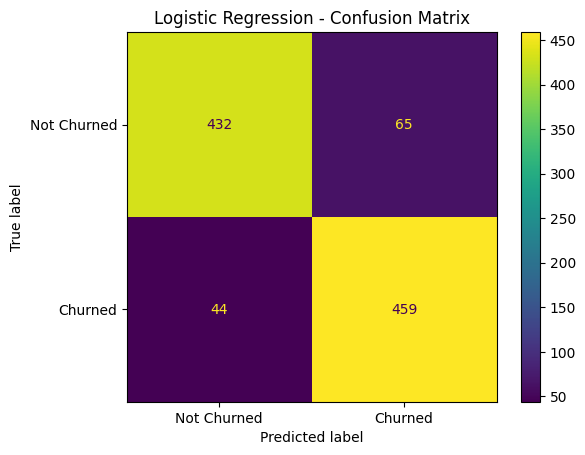

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Churned", "Churned"]
).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [60]:
from sklearn.ensemble import GradientBoostingClassifier

In [61]:
gradient_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

In [62]:
gradient_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [63]:
y_pred_gb = gradient_model.predict(X_test)

y_prob_gb = gradient_model.predict_proba(X_test)[:, 1]

In [64]:
print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall   :", recall_score(y_test, y_pred_gb))
print("F1 Score :", f1_score(y_test, y_pred_gb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_gb))

Accuracy : 0.989
Precision: 0.9900398406374502
Recall   : 0.9880715705765407
F1 Score : 0.9890547263681592
ROC-AUC  : 0.9979559264133508


In [65]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Gradient Boosting"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_gb)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_gb)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_gb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_gb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_gb)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.891,0.875954,0.912525,0.893866,0.967443
1,Gradient Boosting,0.989,0.990040,0.988072,0.989055,0.997956


[[492   5]
 [  6 497]]


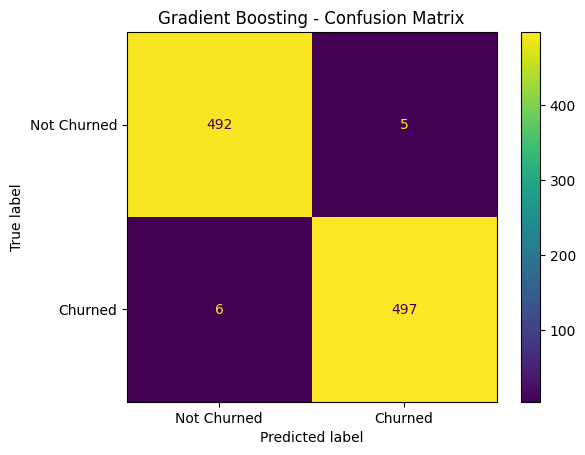

In [66]:
cm_gb = confusion_matrix(y_test, y_pred_gb)

print(cm_gb)

ConfusionMatrixDisplay(
    confusion_matrix=cm_gb,
    display_labels=["Not Churned", "Churned"]
).plot()

plt.title("Gradient Boosting - Confusion Matrix")
plt.show()

In [67]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    gradient_model,
    X,
    y,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    n_jobs=-1
)

print("Mean Accuracy :", cv_results["test_accuracy"].mean())
print("Mean Precision:", cv_results["test_precision"].mean())
print("Mean Recall   :", cv_results["test_recall"].mean())
print("Mean F1       :", cv_results["test_f1"].mean())
print("Mean ROC-AUC  :", cv_results["test_roc_auc"].mean())

Mean Accuracy : 0.9885999999999999
Mean Precision: 0.9936269934798568
Mean Recall   : 0.9836978131212722
Mean F1       : 0.9885776150186208
Mean ROC-AUC  : 0.9990327651795464


In [68]:
feature_names = gradient_model.named_steps[
    "preprocessor"
].get_feature_names_out()

feature_names

array(['categorical__gender_Female', 'categorical__gender_Male',
       'categorical__gender_Other',
       'categorical__subscription_type_Basic',
       'categorical__subscription_type_Premium',
       'categorical__subscription_type_Standard',
       'categorical__region_Africa', 'categorical__region_Asia',
       'categorical__region_Europe', 'categorical__region_North America',
       'categorical__region_Oceania', 'categorical__region_South America',
       'categorical__device_Desktop', 'categorical__device_Laptop',
       'categorical__device_Mobile', 'categorical__device_TV',
       'categorical__device_Tablet',
       'categorical__payment_method_Credit Card',
       'categorical__payment_method_Crypto',
       'categorical__payment_method_Debit Card',
       'categorical__payment_method_Gift Card',
       'categorical__payment_method_PayPal',
       'categorical__favorite_genre_Action',
       'categorical__favorite_genre_Comedy',
       'categorical__favorite_genre_Document

In [69]:
importances = gradient_model.named_steps[
    "classifier"
].feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

feature_importance.head(15)

,feature,importance
34,remainder__avg_watch_time_per_day,0.642099
30,remainder__watch_hours,0.102551
31,remainder__last_login_days,0.085178
33,remainder__number_of_profiles,0.084639
3,categorical__subscription_type_Basic,0.030921
32,remainder__monthly_fee,0.024561
18,categorical__payment_method_Crypto,0.016367
20,categorical__payment_method_Gift Card,0.012230
19,categorical__payment_method_Debit Card,0.000776
21,categorical__payment_method_PayPal,0.000348


In [70]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    gradient_model,
    X,
    y,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    n_jobs=-1
)

print("Mean Accuracy :", cv_results["test_accuracy"].mean())
print("Mean Precision:", cv_results["test_precision"].mean())
print("Mean Recall   :", cv_results["test_recall"].mean())
print("Mean F1       :", cv_results["test_f1"].mean())
print("Mean ROC-AUC  :", cv_results["test_roc_auc"].mean())

Mean Accuracy : 0.9885999999999999
Mean Precision: 0.9936269934798568
Mean Recall   : 0.9836978131212722
Mean F1       : 0.9885776150186208
Mean ROC-AUC  : 0.9990327651795464


In [71]:
feature_names = gradient_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = gradient_model.named_steps[
    "classifier"
].feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

feature_importance.head(15)

,feature,importance
34,remainder__avg_watch_time_per_day,0.642099
30,remainder__watch_hours,0.102551
31,remainder__last_login_days,0.085178
33,remainder__number_of_profiles,0.084639
3,categorical__subscription_type_Basic,0.030921
32,remainder__monthly_fee,0.024561
18,categorical__payment_method_Crypto,0.016367
20,categorical__payment_method_Gift Card,0.012230
19,categorical__payment_method_Debit Card,0.000776
21,categorical__payment_method_PayPal,0.000348


In [72]:
import shap

print(shap.__version__)

0.52.0


In [73]:
X_test_transformed = gradient_model.named_steps[
    "preprocessor"
].transform(X_test)

print(X_test_transformed.shape)

(1000, 35)


In [74]:
explainer = shap.TreeExplainer(
    gradient_model.named_steps["classifier"]
)

In [75]:
shap_values = explainer.shap_values(
    X_test_transformed
)

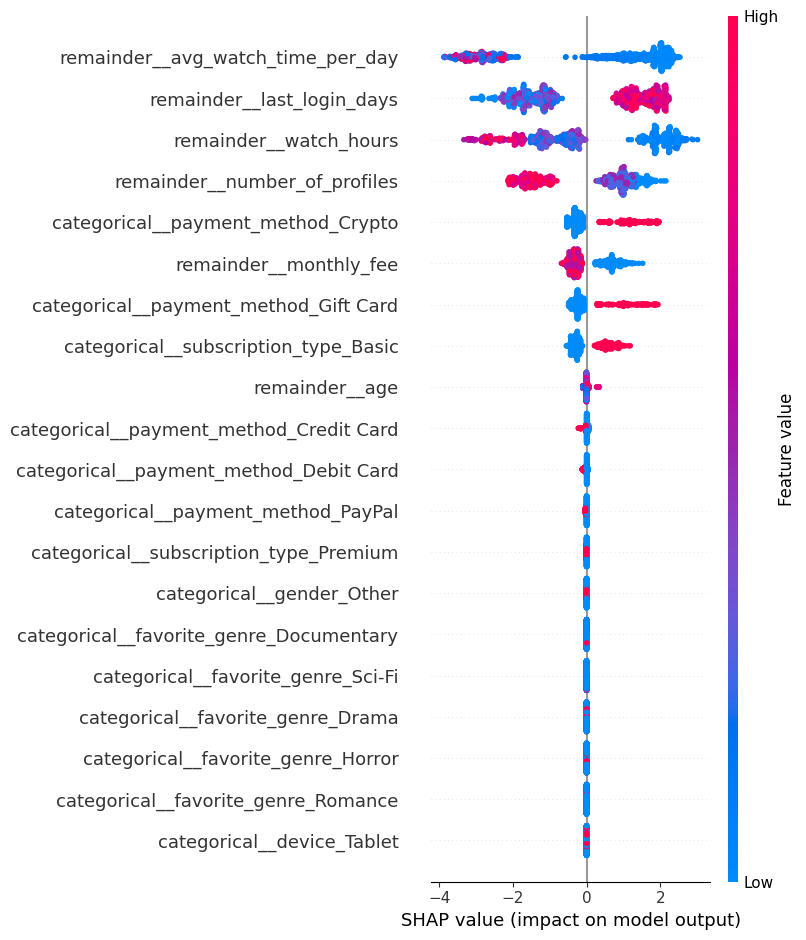

In [76]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

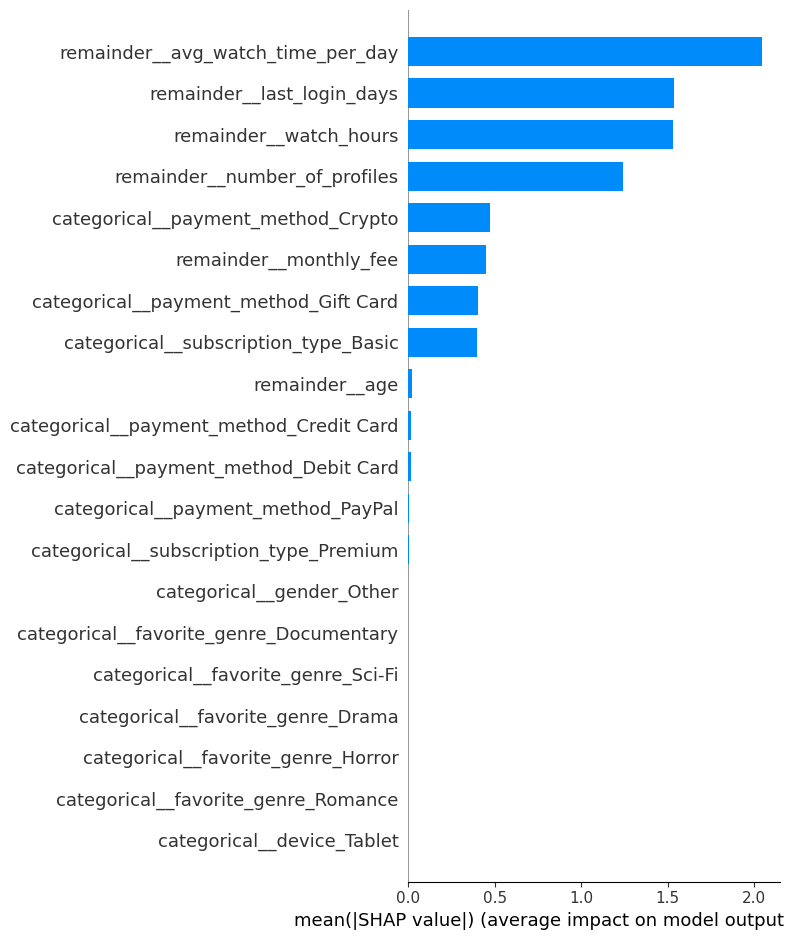

In [77]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

In [78]:
risk_df = X_test.copy()

risk_df["churn_probability"] = y_prob_gb

risk_df["risk"] = pd.cut(
    risk_df["churn_probability"],
    bins=[0, 0.30, 0.70, 1.0],
    labels=["Low", "Medium", "High"]
)

risk_df = risk_df.sort_values(
    "churn_probability",
    ascending=False
)

risk_df.head(10)

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,churn_probability,risk
1347,35,Female,Basic,5.00,48,Africa,Desktop,8.99,Crypto,1,0.10,Drama,0.999573,High
1362,70,Female,Basic,2.46,53,South America,Laptop,8.99,Crypto,1,0.05,Drama,0.999567,High
4588,33,Male,Basic,3.15,42,North America,Mobile,8.99,Crypto,1,0.07,Drama,0.999567,High
3403,59,Female,Basic,2.44,55,Africa,Tablet,8.99,Crypto,1,0.04,Comedy,0.999567,High
4587,22,Other,Basic,0.91,39,South America,Tablet,8.99,Crypto,1,0.02,Drama,0.999567,High
3216,44,Other,Basic,1.06,37,Asia,Desktop,8.99,Crypto,1,0.03,Comedy,0.999567,High
3564,65,Male,Basic,0.14,16,South America,Mobile,8.99,Gift Card,1,0.01,Drama,0.999517,High
313,70,Female,Basic,3.99,24,Africa,Laptop,8.99,Gift Card,1,0.16,Horror,0.999506,High
1153,34,Female,Basic,7.93,60,Asia,Desktop,8.99,Crypto,1,0.13,Action,0.999401,High
1315,18,Female,Basic,5.19,37,South America,Tablet,8.99,Crypto,1,0.14,Romance,0.999401,High


In [79]:
customer_index = risk_df.index[0]

customer = X_test.loc[customer_index]

print(customer)
print(
    "Churn Probability:",
    y_prob_gb[list(X_test.index).index(customer_index)]
)

age                            35
gender                     Female
subscription_type           Basic
watch_hours                   5.0
last_login_days                48
region                     Africa
device                    Desktop
monthly_fee                  8.99
payment_method             Crypto
number_of_profiles              1
avg_watch_time_per_day        0.1
favorite_genre              Drama
Name: 1347, dtype: object
Churn Probability: 0.9995731783952548


In [80]:
row_position = X_test.index.get_loc(customer_index)

customer_shap = shap_values[row_position]

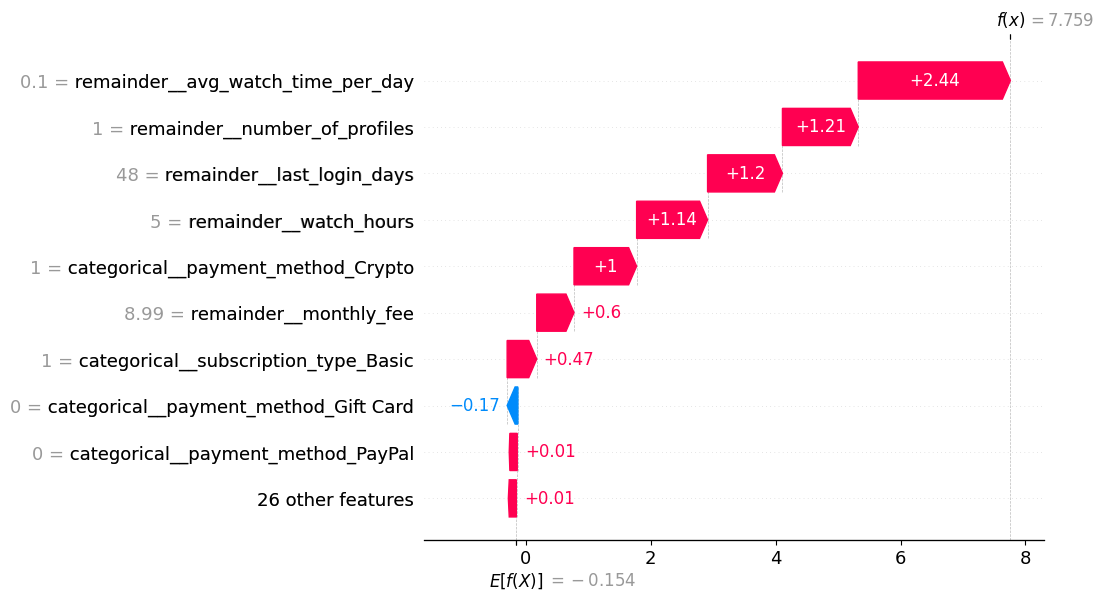

In [81]:
shap.plots.waterfall(
    shap.Explanation(
        values=customer_shap,
        base_values=explainer.expected_value,
        data=X_test_transformed[row_position],
        feature_names=feature_names
    ),
    max_display=10
)

In [82]:
customer_risk = X_test.copy()

customer_risk["churn_probability"] = y_prob_gb

customer_risk["risk_level"] = pd.cut(
    customer_risk["churn_probability"],
    bins=[0, 0.30, 0.70, 1.0],
    labels=["Low", "Medium", "High"]
)

customer_risk[
    [
        "churn_probability",
        "risk_level"
    ]
].head()

,churn_probability,risk_level
1911,0.000460,Low
3551,0.909744,High
1241,0.111397,Low
3182,0.994566,High
3678,0.988549,High


In [83]:
customer_risk.sort_values(
    "churn_probability",
    ascending=False
).head(20)

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,churn_probability,risk_level
1347,35,Female,Basic,5.00,48,Africa,Desktop,8.99,Crypto,1,0.10,Drama,0.999573,High
1362,70,Female,Basic,2.46,53,South America,Laptop,8.99,Crypto,1,0.05,Drama,0.999567,High
4588,33,Male,Basic,3.15,42,North America,Mobile,8.99,Crypto,1,0.07,Drama,0.999567,High
3403,59,Female,Basic,2.44,55,Africa,Tablet,8.99,Crypto,1,0.04,Comedy,0.999567,High
4587,22,Other,Basic,0.91,39,South America,Tablet,8.99,Crypto,1,0.02,Drama,0.999567,High
3216,44,Other,Basic,1.06,37,Asia,Desktop,8.99,Crypto,1,0.03,Comedy,0.999567,High
3564,65,Male,Basic,0.14,16,South America,Mobile,8.99,Gift Card,1,0.01,Drama,0.999517,High
313,70,Female,Basic,3.99,24,Africa,Laptop,8.99,Gift Card,1,0.16,Horror,0.999506,High
1153,34,Female,Basic,7.93,60,Asia,Desktop,8.99,Crypto,1,0.13,Action,0.999401,High
1315,18,Female,Basic,5.19,37,South America,Tablet,8.99,Crypto,1,0.14,Romance,0.999401,High


In [84]:
def recommend_action(row):

    actions = []

    if row["last_login_days"] > 30:
        actions.append("Send re-engagement campaign")

    if row["watch_hours"] < 10:
        actions.append("Recommend personalized content")

    if row["avg_watch_time_per_day"] < 1:
        actions.append("Promote short/trending content")

    if row["subscription_type"] == "Basic":
        actions.append("Offer targeted upgrade incentive")

    if row["payment_method"] == "Crypto":
        actions.append("Review payment experience")

    if not actions:
        actions.append("Maintain engagement")

    return " | ".join(actions)

In [85]:
customer_risk["recommended_action"] = customer_risk.apply(
    recommend_action,
    axis=1
)

In [86]:
customer_risk[
    [
        "churn_probability",
        "risk_level",
        "recommended_action"
    ]
].sort_values(
    "churn_probability",
    ascending=False
).head(10)

,churn_probability,risk_level,recommended_action
1347,0.999573,High,Send re-engagement campaign | Recommend person...
1362,0.999567,High,Send re-engagement campaign | Recommend person...
4588,0.999567,High,Send re-engagement campaign | Recommend person...
3403,0.999567,High,Send re-engagement campaign | Recommend person...
4587,0.999567,High,Send re-engagement campaign | Recommend person...
3216,0.999567,High,Send re-engagement campaign | Recommend person...
3564,0.999517,High,Recommend personalized content | Promote short...
313,0.999506,High,Recommend personalized content | Promote short...
1153,0.999401,High,Send re-engagement campaign | Recommend person...
1315,0.999401,High,Send re-engagement campaign | Recommend person...


In [87]:
customer_index = customer_risk["churn_probability"].idxmax()

customer = customer_risk.loc[customer_index]

customer

age                                                                      35
gender                                                               Female
subscription_type                                                     Basic
watch_hours                                                             5.0
last_login_days                                                          48
region                                                               Africa
device                                                              Desktop
monthly_fee                                                            8.99
payment_method                                                       Crypto
number_of_profiles                                                        1
avg_watch_time_per_day                                                  0.1
favorite_genre                                                        Drama
churn_probability                                                  0.999573
risk_level  

In [88]:
print("========== CUSTOMER CHURN REPORT ==========")

print("\nCustomer Profile:")
print(customer)

print("\nChurn Probability:")
print(f"{customer['churn_probability']:.2%}")

print("\nRisk Level:")
print(customer["risk_level"])

print("\nRecommended Action:")
print(customer["recommended_action"])

========== CUSTOMER CHURN REPORT ==========

Customer Profile:
age                                                                      35
gender                                                               Female
subscription_type                                                     Basic
watch_hours                                                             5.0
last_login_days                                                          48
region                                                               Africa
device                                                              Desktop
monthly_fee                                                            8.99
payment_method                                                       Crypto
number_of_profiles                                                        1
avg_watch_time_per_day                                                  0.1
favorite_genre                                                        Drama
churn_probability        

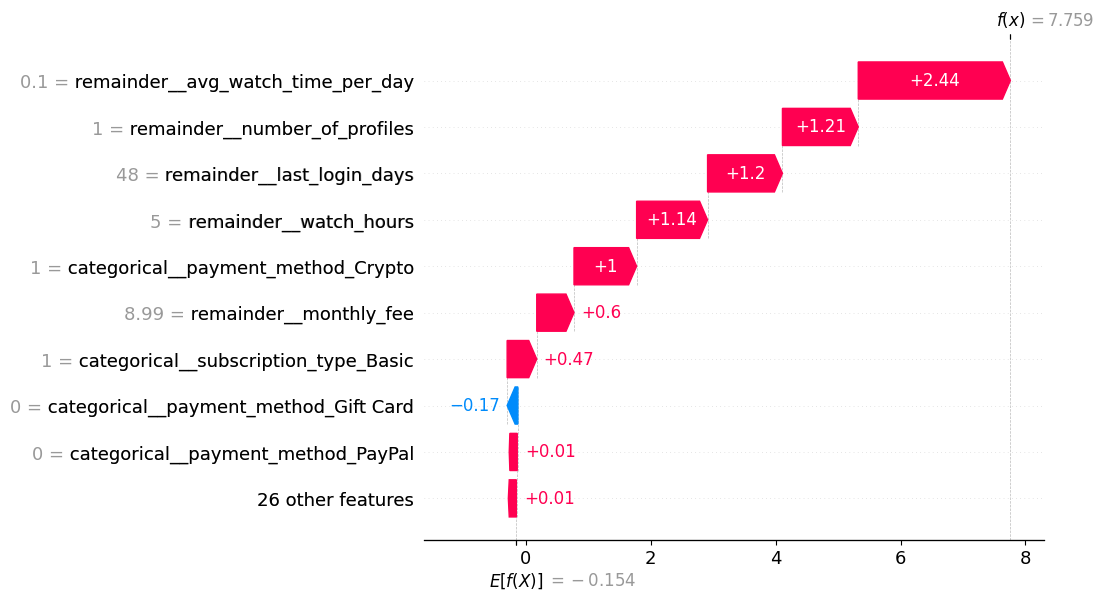

In [89]:
row_position = X_test.index.get_loc(customer_index)

customer_shap = shap_values[row_position]

shap.plots.waterfall(
    shap.Explanation(
        values=customer_shap,
        base_values=explainer.expected_value,
        data=X_test_transformed[row_position],
        feature_names=feature_names
    ),
    max_display=10
)

In [90]:
def recommend_action(row):

    actions = []

    # Engagement problem
    if row["avg_watch_time_per_day"] < 1:
        actions.append("Personalized content recommendations")

    # Inactivity problem
    if row["last_login_days"] > 30:
        actions.append("Re-engagement campaign")

    # Low overall usage
    if row["watch_hours"] < 10:
        actions.append("Promote trending/short-form content")

    # Subscription-related
    if row["subscription_type"] == "Basic":
        actions.append("Targeted retention or upgrade offer")

    # Payment-related
    if row["payment_method"] in ["Crypto", "Gift Card"]:
        actions.append("Review payment experience")

    if not actions:
        actions.append("Maintain engagement")

    return " | ".join(actions)

In [91]:
customer_risk["recommended_action"] = customer_risk.apply(
    recommend_action,
    axis=1
)

In [92]:
final_risk_table = customer_risk[
    [
        "age",
        "subscription_type",
        "watch_hours",
        "last_login_days",
        "monthly_fee",
        "payment_method",
        "number_of_profiles",
        "avg_watch_time_per_day",
        "churn_probability",
        "risk_level",
        "recommended_action"
    ]
].sort_values(
    "churn_probability",
    ascending=False
)

final_risk_table.head(20)

,age,subscription_type,watch_hours,last_login_days,monthly_fee,payment_method,number_of_profiles,avg_watch_time_per_day,churn_probability,risk_level,recommended_action
1347,35,Basic,5.00,48,8.99,Crypto,1,0.10,0.999573,High,Personalized content recommendations | Re-enga...
1362,70,Basic,2.46,53,8.99,Crypto,1,0.05,0.999567,High,Personalized content recommendations | Re-enga...
4588,33,Basic,3.15,42,8.99,Crypto,1,0.07,0.999567,High,Personalized content recommendations | Re-enga...
3403,59,Basic,2.44,55,8.99,Crypto,1,0.04,0.999567,High,Personalized content recommendations | Re-enga...
4587,22,Basic,0.91,39,8.99,Crypto,1,0.02,0.999567,High,Personalized content recommendations | Re-enga...
3216,44,Basic,1.06,37,8.99,Crypto,1,0.03,0.999567,High,Personalized content recommendations | Re-enga...
3564,65,Basic,0.14,16,8.99,Gift Card,1,0.01,0.999517,High,Personalized content recommendations | Promote...
313,70,Basic,3.99,24,8.99,Gift Card,1,0.16,0.999506,High,Personalized content recommendations | Promote...
1153,34,Basic,7.93,60,8.99,Crypto,1,0.13,0.999401,High,Personalized content recommendations | Re-enga...
1315,18,Basic,5.19,37,8.99,Crypto,1,0.14,0.999401,High,Personalized content recommendations | Re-enga...


In [93]:
X_reduced = X.drop(
    columns=[
        "avg_watch_time_per_day",
        "watch_hours",
        "last_login_days"
    ]
)

print(X_reduced.shape)

(5000, 9)


In [94]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [95]:
preprocessor_r = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [96]:
gradient_model_r = Pipeline([
    ("preprocessor", preprocessor_r),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

In [97]:
gradient_model_r.fit(
    X_train_r,
    y_train_r
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [98]:
y_pred_r = gradient_model_r.predict(X_test_r)
y_prob_r = gradient_model_r.predict_proba(X_test_r)[:, 1]

print("Accuracy :", accuracy_score(y_test_r, y_pred_r))
print("Precision:", precision_score(y_test_r, y_pred_r))
print("Recall   :", recall_score(y_test_r, y_pred_r))
print("F1       :", f1_score(y_test_r, y_pred_r))
print("ROC-AUC  :", roc_auc_score(y_test_r, y_prob_r))

Accuracy : 0.59
Precision: 0.5756097560975609
Recall   : 0.7037773359840954
F1       : 0.6332737030411449
ROC-AUC  : 0.6304626966570797


In [99]:
# Final model trained on the complete dataset

final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

final_model.fit(X, y)

print("Final model trained on:", X.shape)

Final model trained on: (5000, 12)


In [100]:
# Predict churn probability for all customers

all_probabilities = final_model.predict_proba(X)[:, 1]

customer_risk = df.copy()

customer_risk["churn_probability"] = all_probabilities

customer_risk["risk_level"] = pd.cut(
    customer_risk["churn_probability"],
    bins=[0, 0.30, 0.70, 1.0],
    labels=["Low", "Medium", "High"]
)

customer_risk.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,churn_probability,risk_level
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action,0.831064,High
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi,0.852007,High
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama,0.006512,Low
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror,0.975003,High
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action,0.993005,High


In [101]:
def recommend_action(row):

    actions = []

    # Engagement
    if row["avg_watch_time_per_day"] < 1:
        actions.append("Personalized content recommendations")

    # Inactivity
    if row["last_login_days"] > 30:
        actions.append("Re-engagement campaign")

    # Low usage
    if row["watch_hours"] < 10:
        actions.append("Promote trending/short-form content")

    # Subscription
    if row["subscription_type"] == "Basic":
        actions.append("Targeted retention or upgrade offer")

    # Payment
    if row["payment_method"] in ["Crypto", "Gift Card"]:
        actions.append("Review payment experience")

    if not actions:
        actions.append("Maintain engagement")

    return " | ".join(actions)


customer_risk["recommended_action"] = customer_risk.apply(
    recommend_action,
    axis=1
)

In [102]:
final_risk_table = customer_risk[
    [
        "customer_id",
        "age",
        "subscription_type",
        "watch_hours",
        "last_login_days",
        "monthly_fee",
        "payment_method",
        "number_of_profiles",
        "avg_watch_time_per_day",
        "churn_probability",
        "risk_level",
        "recommended_action"
    ]
].sort_values(
    "churn_probability",
    ascending=False
)

final_risk_table.head(20)

,customer_id,age,subscription_type,watch_hours,last_login_days,monthly_fee,payment_method,number_of_profiles,avg_watch_time_per_day,churn_probability,risk_level,recommended_action
1284,b41e00a2-10d7-46ae-a151-2cc315df1c34,56,Basic,4.78,51,8.99,Gift Card,1,0.09,0.999763,High,Personalized content recommendations | Re-enga...
3741,8b412cdc-c03a-456c-af50-3d045bc026ee,18,Basic,4.91,44,8.99,Gift Card,1,0.11,0.999763,High,Personalized content recommendations | Re-enga...
1502,e9063abe-14f1-4a30-ac69-04109b0bd3a6,34,Basic,0.35,57,8.99,Gift Card,1,0.01,0.999731,High,Personalized content recommendations | Re-enga...
4814,b7b3766d-a554-4590-930c-4fac22ad5609,65,Basic,1.64,43,8.99,Gift Card,1,0.04,0.999731,High,Personalized content recommendations | Re-enga...
1059,a51a0fca-f883-4bde-9acb-a7dd51f56f09,22,Basic,0.80,35,8.99,Gift Card,1,0.02,0.999731,High,Personalized content recommendations | Re-enga...
390,1abd56c9-1fde-473b-89cd-f9d78879fc10,45,Basic,4.59,47,8.99,Gift Card,1,0.10,0.999731,High,Personalized content recommendations | Re-enga...
1882,41816b3f-56f6-43bf-9115-971ba7dc242f,45,Basic,3.95,38,8.99,Gift Card,1,0.10,0.999731,High,Personalized content recommendations | Re-enga...
4499,cb536c36-8a1e-41b7-ac20-43f09a4cedbd,28,Basic,0.79,40,8.99,Gift Card,1,0.02,0.999731,High,Personalized content recommendations | Re-enga...
4357,c090572e-263a-422d-9829-d167bf0e98fa,59,Basic,1.36,57,8.99,Gift Card,1,0.02,0.999731,High,Personalized content recommendations | Re-enga...
1347,561b865b-5d18-4836-b50e-f40bde688bcf,35,Basic,5.00,48,8.99,Crypto,1,0.10,0.999684,High,Personalized content recommendations | Re-enga...


In [103]:
final_risk_table.to_csv(
    "customer_churn_risk_predictions.csv",
    index=False
)

print("Risk predictions exported successfully.")

Risk predictions exported successfully.


In [104]:
import joblib

joblib.dump(
    final_model,
    "gradient_boosting_churn_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.
